In [2]:

import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats
import importlib
import multi_exp_log
sys.path.append('..')
import plot_settings

import GP

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(multi_exp_log)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

import warnings
warnings.filterwarnings("ignore", message=".*__array_wrap__.*")

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


# Importing data

In [3]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [9]:


def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)','soc_cell (1)','_']
    df.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue', 'soc','_']

    # Sort by time within each batch
    return df


path = f'test_data_soc_5C'

data1 = read_data(path)
data1.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue', 'soc','_']
       #'dV', 'dF', 'soc']

display(data1.head())

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_3142/2028616529.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,u_par,C,t,V,I,F,u,Ue,soc,_
0,0,5,0,4.156921,-24.891078,1.250085e+03,0,4.324992,0.999997,-12.445539
1,0,5,1,4.102482,-24.891078,1.069922e+06,0,4.320771,0.998611,-24.891078
2,0,5,2,4.081310,-24.891078,2.140735e+06,0,4.316542,0.997222,-24.891078
3,0,5,3,4.063704,-24.891078,3.211548e+06,0,4.312312,0.995833,-24.891078
4,0,5,4,4.048277,-24.891078,4.282362e+06,0,4.308083,0.994444,-24.891078


Text(0.5, 0, 'Time (s)')

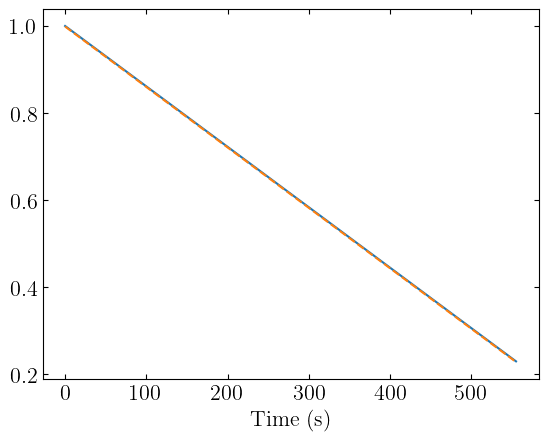

In [15]:
def SOC(Z_init, I, Q = Q0, dt = DT):
    return Z_init - I * dt / Q

soc = []
for i in range(len(data1)):
    if i == 0:
        soc.append(SOC(1, -data1['I'][i]))
    else:
        soc.append(SOC(soc[-1], -data1['I'][i]))

plt.plot(data1['t'], data1['soc'], label='Measured SOC')
plt.plot(data1['t'], soc, label='Calculated SOC', ls = '--')
plt.xlabel('Time (s)')

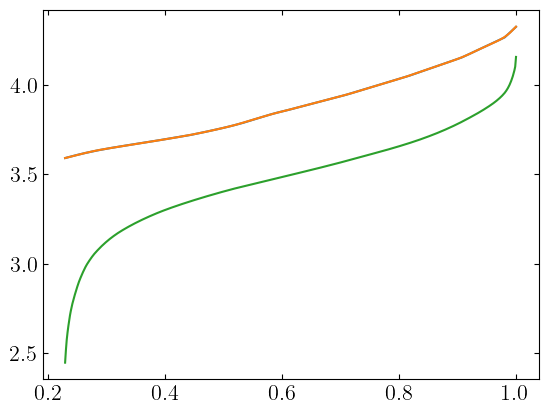

In [18]:
plt.plot(data1['soc'],data1['Ue'])
plt.plot(data1['soc'],GP.soc_to_Ue(data1['soc'], GP_FIT))
plt.plot(data1['soc'],data1['V'])
#plt.plot(data2['soc'][:-100] - (0.025 * (1-data2['soc'][:-100])))
#plt.plot(data2['soc'][:-100])

In [ ]:
def _predict_np(model, config, I_val, u_val, soc0, T):
    # --- run model ---
    I_b    = torch.tensor([I_val],  dtype=torch.float32)
    u_b    = torch.tensor([u_val],  dtype=torch.float32)
    soc0_b = torch.tensor([soc0],   dtype=torch.float32)
    V, Fr, soc, U1, R1, Fs = model(I_b, u_b, soc0_b, T)
    V   = V[0].numpy();   Fr = Fr[0].numpy()
    soc = soc[0].numpy(); U1 = U1[0].numpy()
    R1  = R1[0].numpy();  Fs = Fs[0].numpy()

    # ks along the trajectory (not returned by forward)
    soc_t  = torch.from_numpy(soc)
    I_norm = torch.full((T,), I_val / model.I_ref)
    u_t    = torch.full((T,), u_val)
    ks = model.ks_net(soc_t, I_norm, u_t).numpy()

    if config['C1_mode'] in ('net'):
        C1 = get_C1(model, scalar=False, soc=soc_t, I_norm=I_norm, u_exp=u_t)
    else:
        C1 = get_C1(model, scalar=True)

    return V, soc, U1, R1, Fs, Fr, ks, C1


def gen_noise(i,u,noise_lvl = 0.):
    C_to_I = 4.72930472709413 / 1.9
    u_par_to_u = 2.587185069984447 / 18.0
    I_max = 5.0 * C_to_I
    u_max = 30. * u_par_to_u

    I_noise_std = noise_lvl * I_max
    u_noise_std = noise_lvl * u_max
    i_noise = torch.normal(0, I_noise_std, size=i.shape, rng=torch.Generator().manual_seed(42))
    u_noise = torch.normal(0, u_noise_std, size=u.shape, rng=torch.Generator().manual_seed(42))
    return i_noise, u_noise

def plot_noisy_inputs(I_val, u_val, noise_lvl = 0.00):
    I_b    = torch.tensor([I_val],  dtype=torch.float32)
    u_b    = torch.tensor([u_val],  dtype=torch.float32)
    i_noise, u_noise = gen_noise(I_b, u_b, noise_lvl = noise_lvl)
    I_noisy = I_b + i_noise
    u_noisy = u_b + u_noise

    f, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].hist(I_noisy.numpy(), bins=20, color=colors[0], alpha=0.7, edgecolor='black')
    ax[0].set_xlabel('Current [A]')
    ax[0].set_ylabel('Frequency')
    ax[1].hist(u_noisy.numpy() * 10, bins=20, color=colors[1], alpha=0.7, edgecolor='black')
    ax[1].set_xlabel('Displacement [µm]')
    ax[1].set_ylabel('Frequency')
    plt.tight_layout()
    return f

def _predict_np_noise(model, config, I_val, u_val, soc0, T, noise_lvl = 0.00):
    # --- run model ---
    I_b    = torch.tensor([I_val],  dtype=torch.float32)
    u_b    = torch.tensor([u_val],  dtype=torch.float32)
    # Add noise to inputs
    i_noise, u_noise = gen_noise(I_b, u_b, noise_lvl = noise_lvl)
    I_b += i_noise
    u_b += u_noise

    soc0_b = torch.tensor([soc0],   dtype=torch.float32)
    V, Fr, soc, U1, R1, Fs = model(I_b, u_b, soc0_b, T)
    V   = V[0].numpy();   Fr = Fr[0].numpy()
    soc = soc[0].numpy(); U1 = U1[0].numpy()
    R1  = R1[0].numpy();  Fs = Fs[0].numpy()

    # ks along the trajectory (not returned by forward)
    soc_t  = torch.from_numpy(soc)
    I_norm = torch.full((T,), I_val / model.I_ref)
    u_t    = torch.full((T,), u_val)
    ks = model.ks_net(soc_t, I_norm, u_t).numpy()

    if config['C1_mode'] in ('net'):
        C1 = get_C1(model, scalar=False, soc=soc_t, I_norm=I_norm, u_exp=u_t)
    else:
        C1 = get_C1(model, scalar=True)

    return V, soc, U1, R1, Fs, Fr, ks, C1


def plot_noisy_preds(model, config, trajs, time=False, title='', n_show=10):
    n = min(n_show, len(trajs))
    fig, axes = plt.subplots(8, n, figsize=(5 * n, 26), squeeze=False)

    model.eval()
    k = model.ks_net.k
    noise_max = 0.1
    noise_lvls = np.linspace(0, noise_max, n)
    rmse_noise = np.zeros((n, len(noise_lvls))) # (traj, noise_lvl)
    if not time:
        for j in trange(n):
            tr = trajs[j]
            for i, noise_lvl in enumerate(noise_lvls):
                V, soc_np, U1, R1, Fs, Fr, ks, C1 = _predict_np_noise(model, config, tr['I'], tr['u'], tr['soc0'], tr['T'], noise_lvl = noise_lvl)
                rmse_noise[j,i] = np.sqrt(np.mean((V - tr['V'])**2))

    std_noise = rmse_noise.std(axis=0)
    mean_noise = rmse_noise.mean(axis=0)
    min_noise = mean_noise - std_noise
    max_noise = mean_noise + std_noise
    f,ax = plt.subplots(1,2, figsize=(8,4))

    ax[0].plot(np.unique(noise_lvls)*100, mean_noise,color = colors[0], label='Mean RMSE', lw = 3, ls = '--')
    
    ax[0].fill_between(np.unique(noise_lvls)*100, min_noise, max_noise, color=colors[0], alpha=0.3, label=r'Mean $\pm\sigma$')
    ax[0].set_xlabel(r'Noise level [\%]')
    ax[0].set_ylabel('RMSE for $V$ [V]')
    ax[0].legend()
    ax[1].hist(rmse_noise[:,0], bins=15, color=colors[1], alpha=0.5, label=fr'${noise_lvls.min()*100:.0f} \%$ noise' , edgecolor='black', orientation='vertical')
    ax[1].hist(rmse_noise[:,-1], bins=15, color=colors[2], alpha=0.5, label=fr'${noise_lvls.max()*100:.0f} \%$ noise' , edgecolor='black',orientation='vertical')
    ax[1].set_yticks([])
    ax[1].legend()
    ax[1].set_xlabel('RMSE for $V$ [V]')
    plt.tight_layout()
    return f


    